In [1]:
import pandas as pd
import sqlite3
import matplotlib.pyplot as plt
plt.style.use('ggplot')

#color palette 
# teal
# pink
# gold
# bisque
# darkslategray


# Global Health Stats

 The purpose of this notebook is to explore my findings to hypothetical questions that I have asked. 

 My desire is to: 
 - Grow in my skills as a disease tracker and data visualizer
 - Investigate the prevalence and incidence rates of global diseases
 - Explain my results in a way that can influence policies 

My dataset was retrieved from [Kaggle.com](https://www.kaggle.com/datasets/malaiarasugraj/global-health-statistics). The CSV file was downloaded and imported into a SQLite database, and a connection was made to retrieve data directly from the database. Let's get started!

## Step 1: Get Data
Set up SQLite database connection and assign the dataset to its own variable for ease of replicability.

In [2]:
db_path = 'new-db.db'
conn = sqlite3.connect(db_path)

Before tackling the first question, I created the temporary table 'staging_table' that retrieves all the data used to answer the first few questions.

In [3]:
staging_table = """
SELECT * 
FROM StagingHealthData
;
"""

## Step 2: Question 1
* What is the incidence rate of the top 5 diseases in the past 10 years (2014-2024) ?

Create another temporary table to display the top five diseases.

Use a function called 'read_sql' to read the SQL database table into a DataFrame. 

In [4]:
top_dis_table = """
SELECT *
FROM Top_Diseases
;
"""
df_staging = pd.read_sql(staging_table, conn)
df_top_diseases = pd.read_sql(top_dis_table, conn)


Use Python functions to query the data and answer the first question. 

In [5]:
df_q1_result = (
    df_staging.merge(
        df_top_diseases, 
        on='Disease_Name', 
        how='inner' 
    )   
    .query('2015 <= Year <= 2025')    
    .groupby(['Disease_Name', 'Year'])['Incidence_Rate']
    .mean()   
    .reset_index(name='Average_Incidence_Rate')    
    .sort_values(by=['Disease_Name', 'Year'], ascending=[True, True])
)
print(df_q1_result)

           Disease_Name  Year  Average_Incidence_Rate
0              COVID-19  2015                7.488977
1              COVID-19  2016                7.511204
2              COVID-19  2017                7.501294
3              COVID-19  2018                7.568195
4              COVID-19  2019                7.639034
5              COVID-19  2020                7.482487
6              COVID-19  2021                7.563590
7              COVID-19  2022                7.584944
8              COVID-19  2023                7.641305
9              COVID-19  2024                7.639665
10              Cholera  2015                7.540458
11              Cholera  2016                7.598238
12              Cholera  2017                7.463325
13              Cholera  2018                7.662347
14              Cholera  2019                7.555352
15              Cholera  2020                7.654748
16              Cholera  2021                7.712193
17              Cholera  202

Create a pivot table and plot results on a line chart. 

(3.0, 8.0)

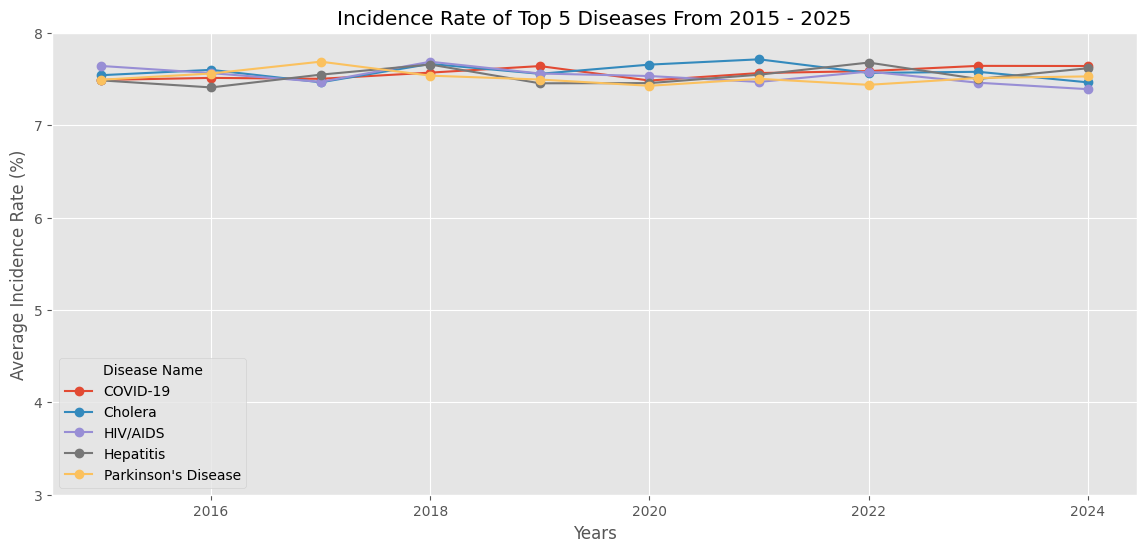

In [ ]:
pivot_df = df_q1_result.pivot_table(
    index="Year",
    columns="Disease_Name",
    values="Average_Incidence_Rate"
)

plt.figure(figsize=(14,6))

for column in pivot_df.columns:
    plt.plot(pivot_df.index, pivot_df[column], marker="o", label=column)

plt.colorbar()
plt.title("Incidence Rate of Top 5 Diseases From 2015 - 2025")
plt.xlabel("Years")
plt.ylabel("Average Incidence Rate (%)")
plt.legend(title="Disease Name")
plt.ylim(3, 8)


** The Y-axis should start at 0%, but zooming in provides a better look at the difference in average incidence rates for the top 5 diseases.**

All top 5 diseases have a similar incidence rate. There were three noticeable peaks for Parkinson's in 2017, Cholera in 2021, and Hepatitis in 2022. 

## Step 3: Question 2
* Which of the top 5 most common diseases have the highest mortality rate globally?

Using a similar method from question 1, query data and calculate the average mortality rate over the past 10 years.

In [7]:
df_q2_result = (
    df_staging.merge(
        df_top_diseases,
        on = 'Disease_Name',
        how='inner'
    )
    .query('2015 <= Year <= 2025')
    .groupby(['Disease_Name', 'Year'])['Mortality_Rate']
    .mean()
    .reset_index(name='Average_Mortality_Rate')
    .sort_values(by=['Disease_Name', 'Year'], ascending=[True, True])
)

print(df_q2_result)

           Disease_Name  Year  Average_Mortality_Rate
0              COVID-19  2015                5.018992
1              COVID-19  2016                5.111258
2              COVID-19  2017                5.055008
3              COVID-19  2018                5.074749
4              COVID-19  2019                5.147939
5              COVID-19  2020                4.978230
6              COVID-19  2021                5.030601
7              COVID-19  2022                4.959837
8              COVID-19  2023                5.012232
9              COVID-19  2024                5.054713
10              Cholera  2015                5.006339
11              Cholera  2016                5.101424
12              Cholera  2017                5.041795
13              Cholera  2018                5.060746
14              Cholera  2019                4.996527
15              Cholera  2020                5.132932
16              Cholera  2021                5.060510
17              Cholera  202

Use resulting data frame to plot another line chart to show the trend over time.

(3.0, 8.0)

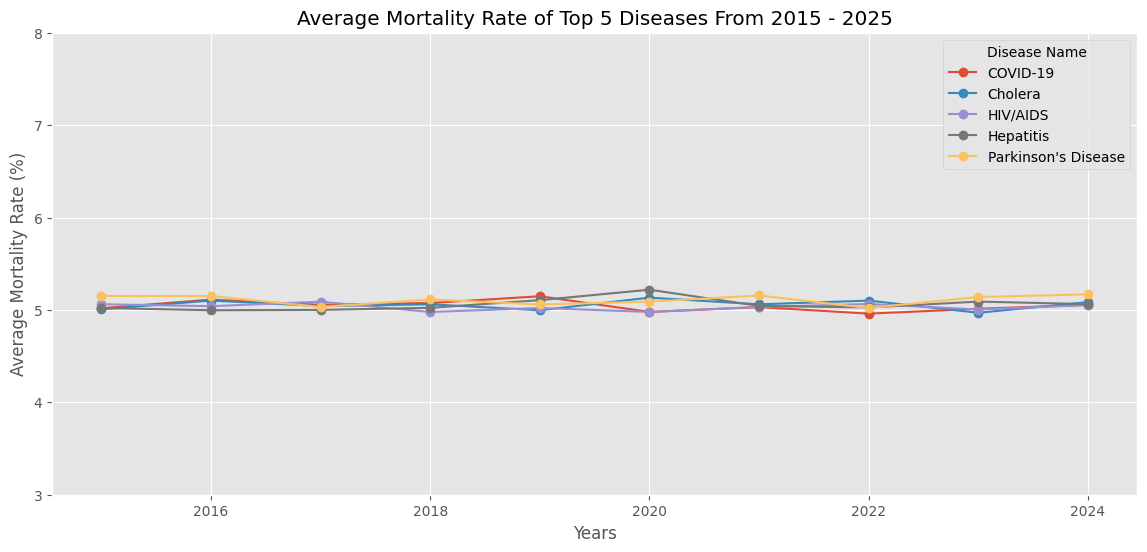

In [8]:
pivot_df = df_q2_result.pivot_table(
    index="Year",
    columns="Disease_Name",
    values="Average_Mortality_Rate"
)

plt.figure(figsize=(14,6))

for column in pivot_df.columns:
    plt.plot(pivot_df.index, pivot_df[column], marker="o", label=column)

plt.title("Average Mortality Rate of Top 5 Diseases From 2015 - 2025")
plt.xlabel("Years")
plt.ylabel("Average Mortality Rate (%)")
plt.legend(title="Disease Name")
plt.ylim(3, 8)

** Y-axis starts at 3% for a better view at the intricacies of the line plot. **

All diseases have a steady average mortality rate of ~ 5% with small fluctuations across the timeline. 

The most notable change in mortality was a decrease of COVID-19 and HIV/AIDS in 2020.

## Step 4: Question 3
* Has there been a decrease in mortality over the last 10 years for the top 5 diseases?

* Which countries had the highest decrease?

In [9]:
cte_query = """
SELECT 
        a.Country, 
        a.Disease_Name, 
        MAX(CASE WHEN CAST(a.Year AS INTEGER) = 2014 THEN a.Mortality_Rate END) AS Rate_2014,
        MAX(CASE WHEN CAST(a.Year AS INTEGER) = 2024 THEN a.Mortality_Rate END) AS Rate_2024
    FROM StagingHealthData a
    JOIN Top_Diseases b ON a.Disease_Name = b.Disease_Name
    GROUP BY a.Country, a.Disease_Name;
"""
q3_df = pd.read_sql_query(cte_query, conn)

q3_df['Total_Rate_Decrease'] = (((q3_df['Rate_2014'] - q3_df['Rate_2024'])/q3_df['Rate_2014'])*100)
top_improvers = q3_df.sort_values(by='Total_Rate_Decrease', ascending=False)
# remove values where there are negative numbers
top_improvers = top_improvers[top_improvers['Total_Rate_Decrease'] > 0]

print(top_improvers[['Country', 'Disease_Name','Total_Rate_Decrease']])

         Country         Disease_Name  Total_Rate_Decrease
5      Australia             COVID-19             2.311558
30       Germany             COVID-19             2.300000
41     Indonesia              Cholera             1.909548
21         China              Cholera             1.703407
25        France             COVID-19             1.503006
54         Japan  Parkinson's Disease             1.407035
85        Turkey             COVID-19             1.310484
74  Saudi Arabia  Parkinson's Disease             1.306533
60       Nigeria             COVID-19             1.302605
95           USA             COVID-19             1.300000
7      Australia             HIV/AIDS             1.212121
59        Mexico  Parkinson's Disease             1.201201
19        Canada  Parkinson's Disease             1.201201
61       Nigeria              Cholera             1.106640
40     Indonesia             COVID-19             1.105528
99           USA  Parkinson's Disease             1.1011

We want to take a closer look at the countries with a total rate of decrease that is greater than 0.

Some countries are repeated more than once, depending on the disease. 

### Using a bar chart, let's compare the countries and the diseases that have experienced the highest total rate of decrease over the past 10 years.

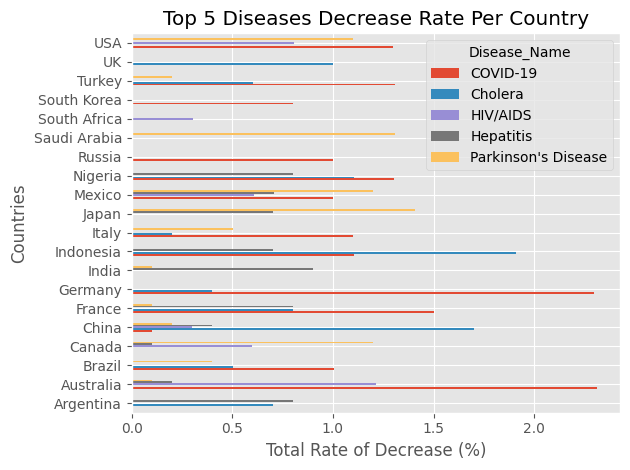

In [10]:

pivot_df_bar = top_improvers.pivot_table(
    index="Country",
    columns="Disease_Name",
    values="Total_Rate_Decrease",
    aggfunc="sum"
)

ax = pivot_df_bar.plot(kind="barh")
ax.set_title("Top 5 Diseases Decrease Rate Per Country")
ax.set_ylabel("Countries")
ax.set_xlabel("Total Rate of Decrease (%)")
plt.tight_layout()
plt.show()

Diseases that have a decreasing rate greater than 1.5% are: COVID-19 and Cholera.

The countries that stand out are: Australia, China, Germany, Indonesia.

Australia and Germany are tied for COVID-19 reaching a decrease rate of greater than 2%. Let's look at those two countries first to compare.

## Question 4

* What socioeconomic factors could contribute to the decreasing mortality rate?

* What is going right? Can it be replicated?

In [32]:
q4_query = """
    SELECT a.Country, a.Disease_Name, Per_Capita_Income, Education_Index, Healthcare_Access
    FROM StagingHealthData a
    JOIN Top_Diseases b
    ON a.Disease_Name = b.Disease_Name
    GROUP BY a.Country, a.Disease_Name
	;
"""
q4_df = pd.read_sql_query(q4_query, conn)

decreased_diseases = ["COVID-19"]
q4_df = q4_df[q4_df['Disease_Name'].isin(decreased_diseases)]

standout_countries = ["Australia" ,  "Germany"]
q4_df = q4_df[q4_df['Country'].isin(standout_countries)]

print(q4_df)

      Country Disease_Name  Per_Capita_Income  Education_Index  \
5   Australia     COVID-19              14702             0.89   
30    Germany     COVID-19              57702             0.51   

    Healthcare_Access  
5               52.03  
30              58.76  


Dive into the 4 countries and look at socioeconomic factors like education, per capita income, and healthcare access.

Starting with COVID-19 in Australia and Germany.

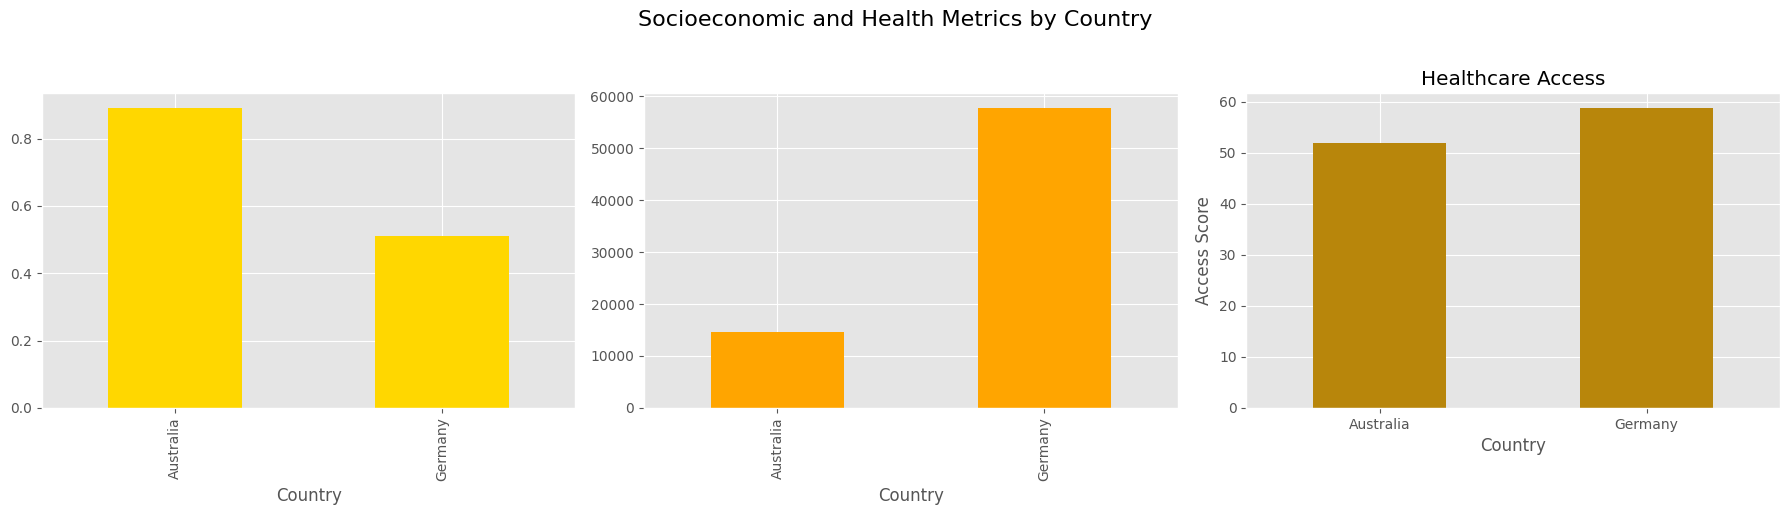

In [ ]:

fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(18, 5), sharex=True)

plot_config = {
   "y_axis": ["Education_Index", "Per_Capita_Income", "Healthcare_Access"],
     "ax": [ax1, ax2, ax3],
     "color": ["gold", "orange", "darkgoldenrod"],
     "graph_title": ["Education Index", "Per Capita Income", "Healthcare Access"],
    "y_label": ["Index Score", "Income (USD)", "Access Score"]
}

for i in range(3):
   current_y = plot_config["y_axis"][i]
   current_ax = plot_config["ax"][i]
   current_color = plot_config["color"][i]
   current_title = plot_config["graph_title"][i]
   current_label = plot_config["y_label"][i]

   q4_df.plot(
        kind='bar', 
        x='Country', 
        y=current_y, 
        ax=current_ax, 
        color=current_color, 
        legend=False
    )
current_ax.set_title(current_title)
current_ax.set_ylabel(current_label)
current_ax.tick_params(axis='x', rotation=0) 


plt.suptitle('Socioeconomic and Health Metrics by Country', fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

The biggest similarity between the two countries is their healthcare access! 

While certainly not causation, it would be plausible to infer that healthcare access has contributed to the decreased rate of COVID-19 in Australia and Germany. 

Next, let's look at Cholera in China and Indonesia.

Set up the data to view the data from the two specified countries. 

In [40]:
q4_query = """
    SELECT a.Country, a.Disease_Name, Per_Capita_Income, Education_Index, Healthcare_Access
    FROM StagingHealthData a
    JOIN Top_Diseases b
    ON a.Disease_Name = b.Disease_Name
    GROUP BY a.Country, a.Disease_Name
	;
"""
q4_df = pd.read_sql_query(q4_query, conn)

decreased_diseases = ["Cholera"]
q4_df = q4_df[q4_df['Disease_Name'].isin(decreased_diseases)]

standout_countries = ["China", "Indonesia"]
q4_df = q4_df[q4_df['Country'].isin(standout_countries)]

print(q4_df)

      Country Disease_Name  Per_Capita_Income  Education_Index  \
21      China      Cholera              53106             0.83   
41  Indonesia      Cholera              48252             0.60   

    Healthcare_Access  
21              64.65  
41              58.80  


Create 3 different plots, keeping the country same, to find the similarities and differences.

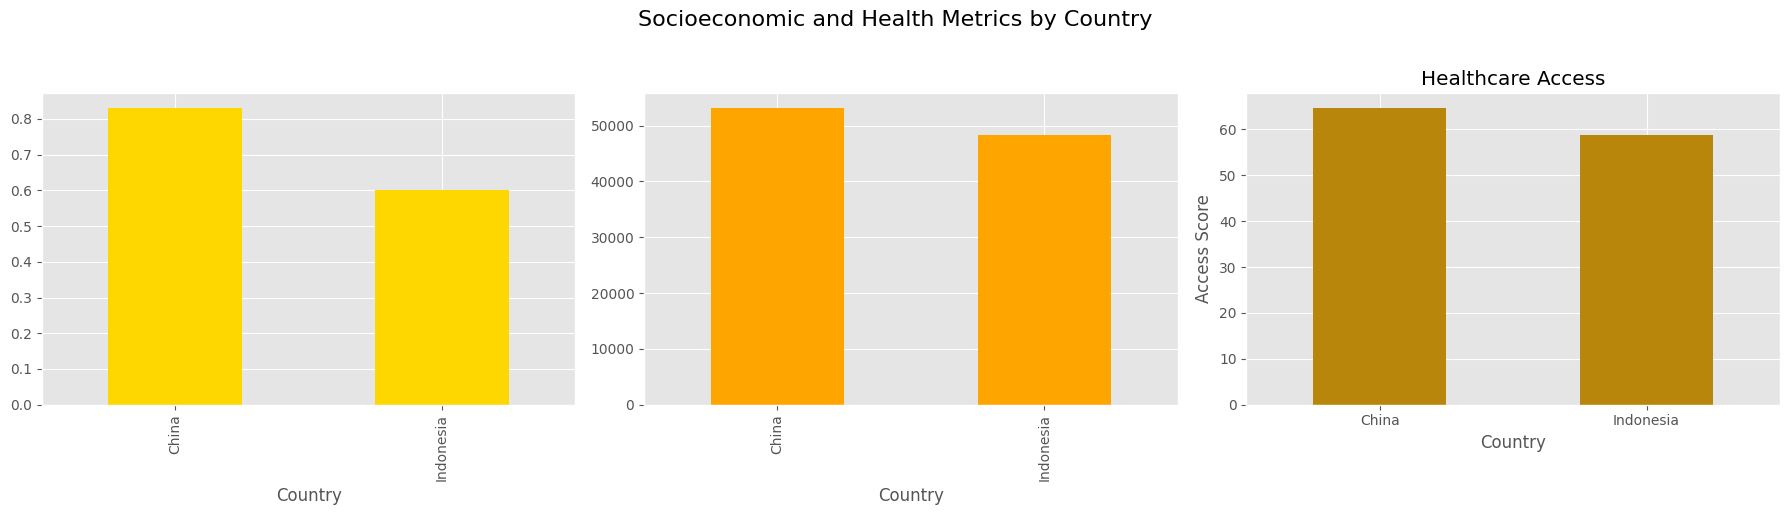

In [42]:
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(18, 5), sharex=True)

plot_config = {
   "y_axis": ["Education_Index", "Per_Capita_Income", "Healthcare_Access"],
     "ax": [ax1, ax2, ax3],
     "color": ["gold", "orange", "darkgoldenrod"],
     "graph_title": ["Education Index", "Per Capita Income", "Healthcare Access"],
    "y_label": ["Index Score", "Income (USD)", "Access Score"]
}

for i in range(3):
   current_y = plot_config["y_axis"][i]
   current_ax = plot_config["ax"][i]
   current_color = plot_config["color"][i]
   current_title = plot_config["graph_title"][i]
   current_label = plot_config["y_label"][i]

   q4_df.plot(
        kind='bar', 
        x='Country', 
        y=current_y, 
        ax=current_ax, 
        color=current_color, 
        legend=False
    )
current_ax.set_title(current_title)
current_ax.set_ylabel(current_label)
current_ax.tick_params(axis='x', rotation=0) 


plt.suptitle('Socioeconomic and Health Metrics by Country', fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

Two similarities can be found in this data when comparing the countries: Per Capita Income and Healthcare Access. 

As previously mentioned, correlation does not equal causation, but it could contribute to the decreased rate of Cholera. 